# FM results — presynaptic silencing after hypoxia

Figures 3–7 and the statistics of Results section 1 / Methods 1.10.

Input: the `overlap_summary.csv` files produced by `get_data_FM_final.py`, under the condition subfolders (`Control_FM_syn`, `Hypoxia_FM_syn_24h`, …). The per-coverslip value is the **unweighted mean** of the per-field silent-synapse percentages; density is the mean synapsin puncta per field.

In [1]:
%matplotlib inline
# --- Imports and global configuration -------------------------------------
import os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats                 # core statistical tests
import scikit_posthocs as sph           # Dunn post-hoc test (imported as sph)

# Repo-relative data path (portable). Works run from Codes/ or repo root;
# override with the FM_DATA_DIR environment variable if needed.
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == 'Codes' else HERE
DATA_DIR = Path(os.environ.get('FM_DATA_DIR', ROOT / 'data' / 'FM_syn'))

# Per-condition plot colour, display label, and canonical order used throughout.
COL = {'C':'#4C72B0','H':'#C44E52','HR':'#55A868'}      # blue / red / green
LAB = {'C':'Control','H':'Hypoxia','HR':'Hypoxia Recovery'}
CONDS = ['C','H','HR']

## 1. Load data (per-coverslip, unweighted mean)

In [ ]:
# --- Analysis constants + data-loading helpers ---------------------------
# Outcome measure: % of synapsin puncta with NO FM signal ("presynaptically silent").
METRIC_RAW    = "pct_syn_with_fm"   # % synapsin puncta that ARE FM+ (active)

METRIC        = "pct_silent"        # % synapsin puncta that are FM- (silent) = 100 - METRIC_RAW

FIELD_EXCLUSIONS = {
    # Fields dropped after quality control. The dense-batch fields below were flagged as poor
    # quality on manual review; the last two entries are registration failures.
    ("Control_FM_syn",   "cs1"): {1, 2, 3, 4, 5, 6, 7, 8, 9, 12},
    ("Control_FM_syn",   "cs2"): {1, 2, 3, 5, 14},
    ("Control_FM_syn",   "cs4"): {10, 16},
    ("Control_FM_syn",   "cs5"): {1},

    ("Hypoxia_FM_syn",   "cs1"): {6, 7, 8, 11, 13, 18},
    ("Hypoxia_FM_syn",   "cs3"): {1, 2, 15},
    ("Hypoxia_FM_syn",   "cs4"): {13},

    ("Hypoxia_recovery_FM_syn", "cs3"): {16},
    ("Hypoxia_recovery_FM_syn", "cs4"): {3, 4},
    ("Hypoxia_recovery_FM_syn", "cs5"): {6},

    ("Control_FM_syn_48h",       "cs1"):  {18},
    ("Hypoxia_FM_syn_48h",       "cs1"):  {5},
    ("Hypoxia_recovery_FM_syn_48h", "cs1"): {17},

    # Channel-registration failures (synapsin/FM misaligned: pixel overlap ~4%
    # vs ~72-75% for the rest of the coverslip -> artefactually ~84% "silent").
    ("Hypoxia_FM_syn_24h", "cs1"): {9, 10},
    ("Hypoxia_recovery_FM_syn_24h", "cs7"): {22, 23, 24},
}
# ============================================================


# ---------------------------------------------------------------------------
# Data loading
# ---------------------------------------------------------------------------

# Infer condition (C/H/HR) from a folder name.
def _detect_condition(name: str):
    n = name.lower()
    if "hypoxia_recovery" in n or "hypoxiarecovery" in n:
        return "HR"
    if "hypoxia" in n:
        return "H"
    if "control" in n or "ctrl" in n:
        return "C"
    return None

# Infer batch from the folder-name suffix: dense (no suffix), 24h, or 48h.
def _detect_batch(cond_folder_name: str):
    n = cond_folder_name.lower()
    if "_48h" in n:
        return "48h"
    if "_24h" in n:
        return "24h"
    return "dense"

def load_all_data(parent: Path) -> pd.DataFrame:
    """Load every overlap_summary.csv, tag with condition/batch/coverslip. One row per field."""
    rows = []
    for cond_folder in sorted(parent.iterdir()):
        if not cond_folder.is_dir():
            continue
        condition = _detect_condition(cond_folder.name)
        if condition is None:
            continue
        batch = _detect_batch(cond_folder.name)

        # each coverslip (cs*) has its own per-field overlap_summary.csv
        nested_csvs = sorted(cond_folder.glob("cs*/puncta_analysis/overlap_summary.csv"))
        if nested_csvs:
            for csv in nested_csvs:
                cs_name = csv.parent.parent.name
                df = pd.read_csv(csv)
                excl = FIELD_EXCLUSIONS.get((cond_folder.name, cs_name), set())
                if excl:                       # drop QC-excluded fields
                    df = df[~df["field"].isin(excl)]
                df["condition"] = condition
                df["batch"] = batch
                df["coverslip"] = f"{cond_folder.name}/{cs_name}"
                rows.append(df)
        else:
            direct_csv = cond_folder / "puncta_analysis" / "overlap_summary.csv"
            if direct_csv.exists():
                df = pd.read_csv(direct_csv)
                excl = FIELD_EXCLUSIONS.get((cond_folder.name, None), set())
                if excl:
                    df = df[~df["field"].isin(excl)]
                df["condition"] = condition
                df["batch"] = batch
                df["coverslip"] = cond_folder.name
                rows.append(df)

    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    # convert the raw "active" percentage into the "silent" percentage
    out[METRIC] = 100 - out[METRIC_RAW]
    return out

In [3]:
# Load all fields (one row per imaged field of view) ...
fields = load_all_data(DATA_DIR)
# ... then collapse to one row per coverslip: mean silent %, mean synapsin count.
# The coverslip is the experimental unit for the statistics below.
cs = (fields.groupby(['batch','condition','coverslip'])
            .agg(silent=('pct_silent','mean'), density=('n_syn','mean')).reset_index())
# Helper: per-coverslip silent% values for a given batch b and condition c.
def g(b,c): return cs[(cs.batch==b)&(cs.condition==c)]['silent'].values
# Quick sanity table: how many coverslips and the median silent% per batch/condition.
print(cs.groupby(['batch','condition']).silent.agg(['size','median']).round(1))

                 size  median
batch condition              
24h   C             5    19.6
      H             9    18.3
      HR           10    21.1
48h   C             8    21.6
      H             8    24.1
      HR            8    20.0
dense C             5    36.1
      H             4    41.8
      HR            5    37.3


## 2. Statistics (Methods 1.10)

In [ ]:
# p-value -> significance stars.
def stars(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
# Holm correction for the two planned comparisons (H vs C, HR vs C) within a batch.
def holm2(p1,p2):
    o=sorted([('H',p1),('HR',p2)],key=lambda z:z[1]); a={}
    a[o[0][0]]=min(o[0][1]*2,1); a[o[1][0]]=max(min(o[1][1],1),a[o[0][0]]); return a

# For each batch: per-condition median/IQR, normality (Shapiro), planned Mann-Whitney
# vs Control (Holm-corrected), and an omnibus Kruskal-Wallis (+ Dunn if significant).
print('=== Within-batch: medians, Shapiro, planned MWU vs Control (Holm), Kruskal-Wallis + Dunn (Bonferroni) ===')
for b,lbl in [('dense','24 h dense'),('24h','24 h sparse'),('48h','48 h sparse')]:
    Cc,H,HR=g(b,'C'),g(b,'H'),g(b,'HR'); print(f'\n[{lbl}]')
    for nm,v in [('Control',Cc),('Hypoxia',H),('HR',HR)]:
        sp=stats.shapiro(v).pvalue if len(v)>=3 else float('nan')   # normality test
        print(f'  {nm:8s} n={len(v):2d}  median={np.median(v):5.1f}  IQR=[{np.percentile(v,25):.1f}, {np.percentile(v,75):.1f}]  Shapiro p={sp:.3f}')
    # planned pairwise vs Control, Holm-corrected
    _,pHC=stats.mannwhitneyu(H,Cc); _,pHRC=stats.mannwhitneyu(HR,Cc); adj=holm2(pHC,pHRC)
    print(f'  H vs C  raw={pHC:.3f} Holm={adj["H"]:.3f} {stars(adj["H"])}   |   HR vs C raw={pHRC:.3f} Holm={adj["HR"]:.3f} {stars(adj["HR"])}')
    
    # omnibus test across the three conditions
    hK,pK=stats.kruskal(Cc,H,HR); print(f'  Kruskal-Wallis H={hK:.2f} p={pK:.3f}')
    if pK<0.05:   # only follow up with Dunn if the omnibus is significant
        pool=pd.DataFrame([('C',x) for x in Cc]+[('H',x) for x in H]+[('HR',x) for x in HR],columns=['gg','v'])
        dn=sph.posthoc_dunn(pool,val_col='v',group_col='gg',p_adjust='bonferroni')
        print(f'  Dunn(Bonferroni) H vs HR p={dn.loc["H","HR"]:.3f} {stars(dn.loc["H","HR"])}')

=== Within-batch: medians, Shapiro, planned MWU vs Control (Holm), Kruskal-Wallis + Dunn (Bonferroni) ===

[24 h dense]
  Control  n= 5  median= 36.1  IQR=[33.1, 36.5]  Shapiro p=0.602
  Hypoxia  n= 4  median= 41.8  IQR=[40.1, 42.8]  Shapiro p=0.573
  HR       n= 5  median= 37.3  IQR=[36.9, 40.6]  Shapiro p=0.255
  H vs C  raw=0.032 Holm=0.063 ns   |   HR vs C raw=0.151 Holm=0.151 ns
  Kruskal-Wallis H=5.40 p=0.067

[24 h sparse]
  Control  n= 5  median= 19.6  IQR=[19.2, 20.1]  Shapiro p=0.263
  Hypoxia  n= 9  median= 18.3  IQR=[17.5, 18.6]  Shapiro p=0.250
  HR       n=10  median= 21.1  IQR=[17.9, 25.2]  Shapiro p=0.487
  H vs C  raw=0.190 Holm=0.380 ns   |   HR vs C raw=0.254 Holm=0.380 ns
  Kruskal-Wallis H=3.62 p=0.164

[48 h sparse]
  Control  n= 8  median= 21.6  IQR=[20.4, 22.5]  Shapiro p=0.505
  Hypoxia  n= 8  median= 24.1  IQR=[23.3, 24.8]  Shapiro p=0.026
  HR       n= 8  median= 20.0  IQR=[18.7, 21.2]  Shapiro p=0.011
  H vs C  raw=0.038 Holm=0.076 ns   |   HR vs C raw=0.130

In [5]:
# --- Duration effect: is 24 h different from 48 h within each condition? ---
print('=== Duration: 24 h vs 48 h per condition (Mann-Whitney U) ===')
for c in CONDS:
    a,b2=g('24h',c),g('48h',c); U,p=stats.mannwhitneyu(a,b2)
    print(f'  {LAB[c]:16s} 24h med={np.median(a):.1f} vs 48h med={np.median(b2):.1f}  U={U:.0f} p={p:.4f} {stars(p)}')

# --- Coverslip-to-coverslip variability: CV% per group, and Levene equal-variance tests ---
print('\n=== Coverslip-to-coverslip variability: CV% and Levene ===')
for b in ['24h','48h']:
    for c in CONDS:
        v=g(b,c); print(f'  {b} {LAB[c]:16s} SD={np.std(v,ddof=1):.2f}  CV={100*np.std(v,ddof=1)/np.mean(v):.1f}%')
allg=[g(b,c) for b in ['24h','48h'] for c in CONDS]
W,p=stats.levene(*allg,center='median'); print(f'  Levene across all six groups: W={W:.2f} p={p:.3f}')
# targeted test: is recovery more variable than the pooled control + hypoxia baseline?
for b in ['24h','48h']:
    HR=g(b,'HR'); pooled=np.concatenate([g(b,'C'),g(b,'H')]); W,p=stats.levene(HR,pooled,center='median')
    print(f'  Levene HR vs pooled C+H, {b}: W={W:.2f} p={p:.3f} {stars(p)}')

# --- Does coverslip synapse density explain its silencing? (Spearman, sparse batches) ---
print('\n=== Synapse density vs silencing (sparse batches) — Spearman ===')
spb=cs[cs.batch.isin(['24h','48h'])]                         # coverslip-level, sparse only
r,p=stats.spearmanr(spb.density,spb.silent); print(f'  overall (n={len(spb)}): r={r:.2f} p={p:.2f}')
for c in CONDS:                                              # and within each condition
    s=spb[spb.condition==c]; r,p=stats.spearmanr(s.density,s.silent); print(f'  {LAB[c]:16s} r={r:.2f} p={p:.2f}')

=== Duration: 24 h vs 48 h per condition (Mann-Whitney U) ===
  Control          24h med=19.6 vs 48h med=21.6  U=4 p=0.0186 *
  Hypoxia          24h med=18.3 vs 48h med=24.1  U=3 p=0.0006 ***
  Hypoxia Recovery 24h med=21.1 vs 48h med=20.0  U=45 p=0.6965 ns

=== Coverslip-to-coverslip variability: CV% and Levene ===
  24h Control          SD=1.01  CV=5.2%
  24h Hypoxia          SD=2.50  CV=13.6%
  24h Hypoxia Recovery SD=4.98  CV=22.6%
  48h Control          SD=1.72  CV=7.9%
  48h Hypoxia          SD=3.08  CV=12.5%
  48h Hypoxia Recovery SD=4.37  CV=20.9%
  Levene across all six groups: W=1.73 p=0.148
  Levene HR vs pooled C+H, 24h: W=7.13 p=0.014 *
  Levene HR vs pooled C+H, 48h: W=0.24 p=0.628 ns

=== Synapse density vs silencing (sparse batches) — Spearman ===
  overall (n=48): r=0.14 p=0.33
  Control          r=-0.03 p=0.93
  Hypoxia          r=0.32 p=0.22
  Hypoxia Recovery r=0.02 p=0.93


## 3. Figures
Shared plotting helpers, then Figures 3–7.

In [6]:
# --- Shared plotting helpers used by the figures below --------------------
rng0=np.random.default_rng
def box_panel(ax,groups,positions,colors,seed):
    """Draw a boxplot per group with jittered individual points overlaid.
    `seed` fixes the horizontal jitter so the figure is reproducible."""
    rng=rng0(seed)
    for pos,v,c in zip(positions,groups,colors):
        if len(v)==0: continue
        ax.boxplot([v],positions=[pos],widths=0.55,patch_artist=True,showfliers=False,
            medianprops=dict(color='black',linewidth=1.6),boxprops=dict(facecolor=c,alpha=0.35,edgecolor=c,linewidth=1.4),
            whiskerprops=dict(color=c,linewidth=1.3),capprops=dict(color=c,linewidth=1.3))
        # jittered points = individual coverslips
        j=rng.uniform(-0.13,0.13,size=len(v)); ax.scatter(pos+j,v,color=c,s=40,alpha=0.9,edgecolors='white',linewidths=0.6,zorder=5)
def bracket(ax,x0,x1,y,label,pad):
    """Draw a significance bracket from x0 to x1 at height y with a text label."""
    ax.plot([x0,x0,x1,x1],[y,y+pad,y+pad,y],color='black',lw=1.1); ax.text((x0+x1)/2,y+pad,label,ha='center',va='bottom',fontsize=12)

### Figure 5 — silencing across conditions, comparable (sparse) batches

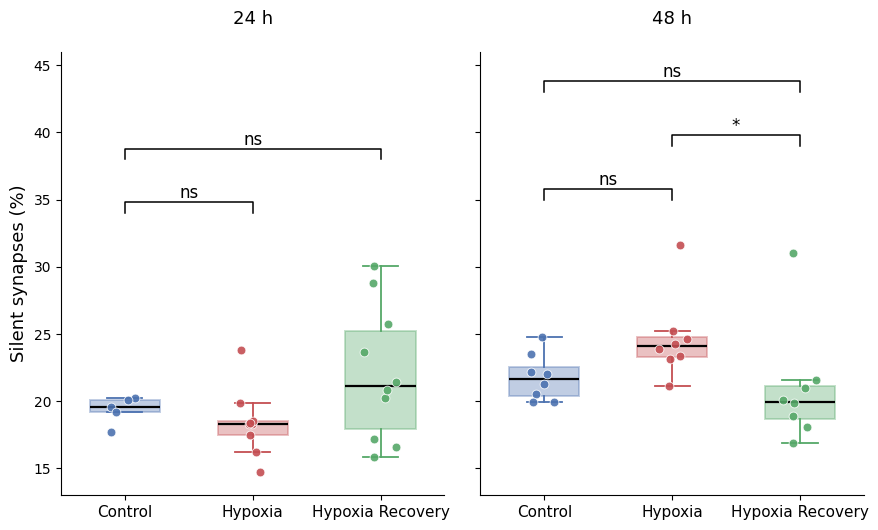

In [7]:
# Figure 5 - presynaptically-silent synapse % across conditions, sparse batches.
# Two panels (24 h, 48 h); each has the three condition boxplots + per-coverslip points.
fig,axes=plt.subplots(1,2,figsize=(9,5.4),sharey=True)
# per panel: batch key, title, and a list of (x_left, x_right, y, label) brackets
for ax,(b,title,brs) in zip(axes,[('24h','24 h',[(1,2,34,'ns'),(1,3,38,'ns')]),('48h','48 h',[(1,2,35,'ns'),(2,3,39,'*'),(1,3,43,'ns')])]):
    box_panel(ax,[g(b,c) for c in CONDS],[1,2,3],[COL[c] for c in CONDS],3)   # seed 3 = fixed jitter
    ax.set_title(title,fontsize=13,pad=20); ax.set_xticks([1,2,3]); ax.set_xticklabels([LAB[c] for c in CONDS],fontsize=11)
    ax.set_ylim(13,46); ax.spines[['top','right']].set_visible(False)
    for x0,x1,y,l in brs: bracket(ax,x0,x1,y,l,0.8)          # add significance brackets
axes[0].set_ylabel('Silent synapses (%)',fontsize=13); fig.tight_layout(); plt.savefig('../figures/Figure5.png', dpi=200, bbox_inches='tight'); plt.show()

### Figure 6 — densely seeded batch (analysed separately)

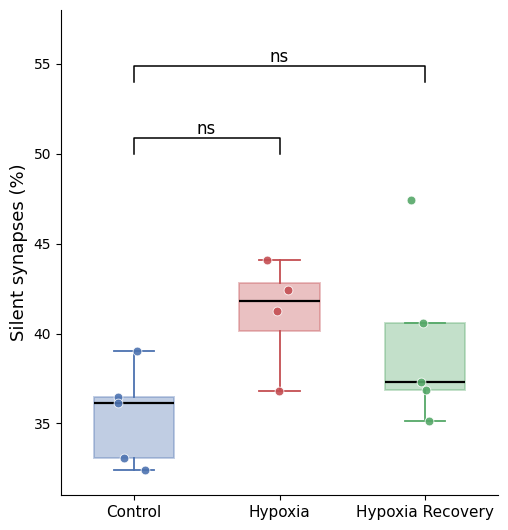

In [8]:
# Figure 6 - the densely-seeded batch, analysed and shown separately (single panel).
fig,ax=plt.subplots(figsize=(5.2,5.4))
box_panel(ax,[g('dense',c) for c in CONDS],[1,2,3],[COL[c] for c in CONDS],3)    # three condition boxes
ax.set_xticks([1,2,3]); ax.set_xticklabels([LAB[c] for c in CONDS],fontsize=11)
ax.set_ylim(31,58); ax.set_ylabel('Silent synapses (%)',fontsize=13); ax.spines[['top','right']].set_visible(False)
bracket(ax,1,2,50,'ns',0.9); bracket(ax,1,3,54,'ns',0.9); fig.tight_layout(); plt.savefig('../figures/Figure6.png', dpi=200, bbox_inches='tight'); plt.show()

### Figure 7 — duration-dependent change (24 h vs 48 h)

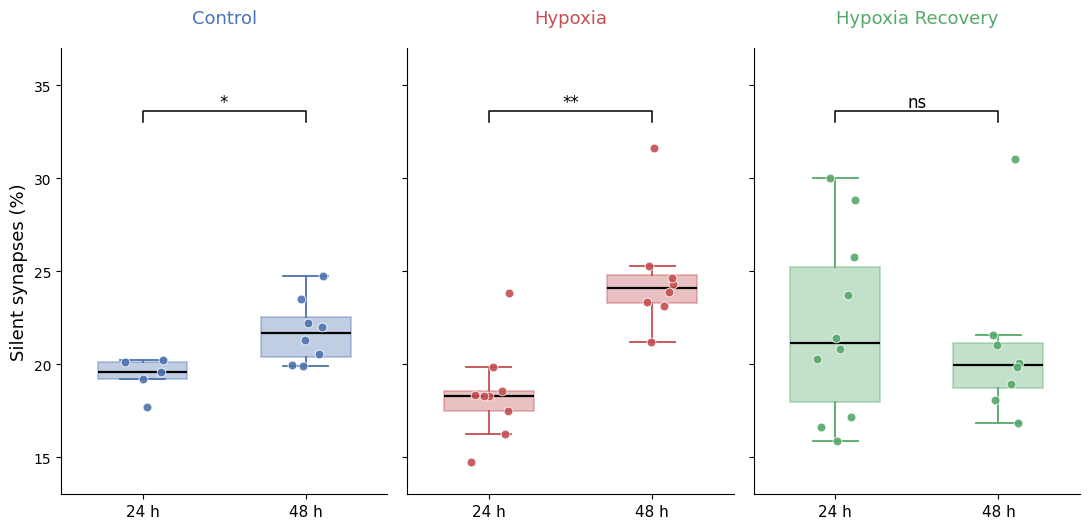

In [9]:
# Figure 7 - duration effect (24 h vs 48 h) shown per condition, one panel each.
# Holm-corrected marks: Control p=0.037 (*), Hypoxia p=0.002 (**), HR p=0.70 (ns).
fig,axes=plt.subplots(1,3,figsize=(11,5.4),sharey=True)
for ax,(c,title,sig) in zip(axes,[('C','Control','*'),('H','Hypoxia','**'),('HR','Hypoxia Recovery','ns')]):
    box_panel(ax,[g('24h',c),g('48h',c)],[1,2],[COL[c],COL[c]],4)     # 24h vs 48h boxes for this condition
    ax.set_title(title,fontsize=13,color=COL[c],pad=18); ax.set_xticks([1,2]); ax.set_xticklabels(['24 h','48 h'],fontsize=11)
    ax.set_ylim(13,37); ax.spines[['top','right']].set_visible(False); bracket(ax,1,2,33,sig,0.6)   # 24h-vs-48h bracket
axes[0].set_ylabel('Silent synapses (%)',fontsize=13); fig.tight_layout(); plt.savefig('../figures/Figure7.png', dpi=200, bbox_inches='tight'); plt.show()

### Figure 8 — coverslip-to-coverslip variability (A: distributions, B: CV%)

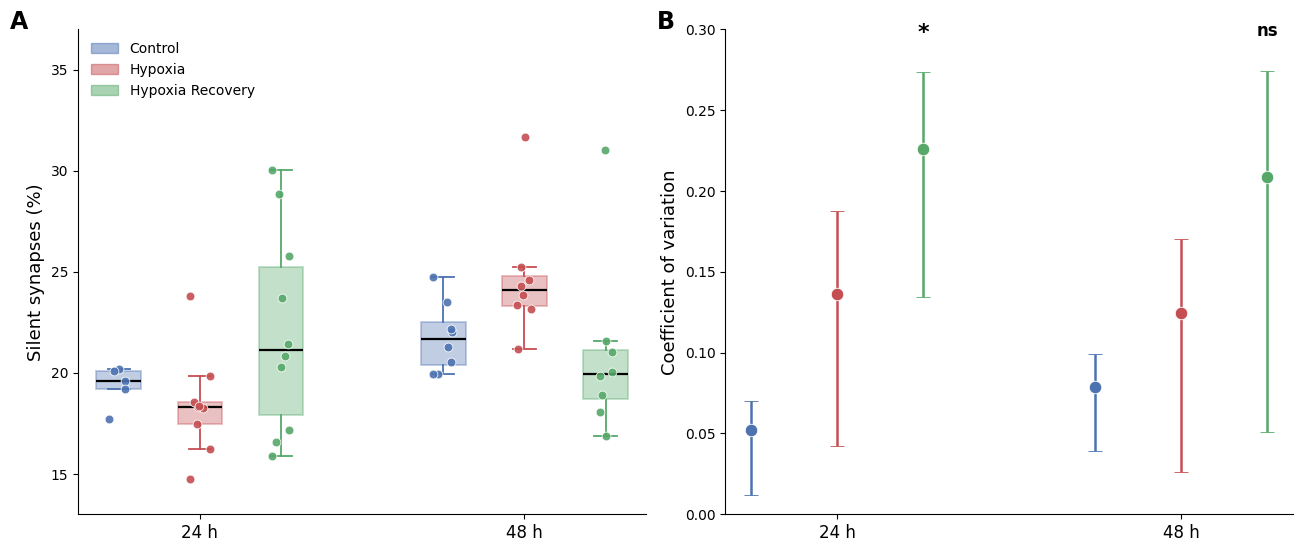

In [10]:
# Figure 8 - coverslip-to-coverslip variability.
# (A) silent-fraction boxplots per condition x duration.
# (B) coefficient of variation (CV = SD/mean) per group as a point with a bootstrap 95% CI;
#     the mark tests whether the bootstrap 95% CI of the DIFFERENCE in CV (hypoxia recovery
#     vs pooled control + hypoxia) excludes zero. Variability (spread), not means, is the outcome,
#     so this is a bootstrap comparison of CVs rather than an ANOVA/Kruskal-Wallis on group location.
from matplotlib.patches import Patch
def _cv(x): return np.std(x, ddof=1) / np.mean(x)
_brng = np.random.default_rng(5)
def _cv_ci(v, n=20000):
    b = [_cv(_brng.choice(v, len(v), replace=True)) for _ in range(n)]
    return np.percentile(b, [2.5, 97.5])
def _diff_excl_zero(hr, pooled, n=20000):
    d = [_cv(_brng.choice(hr, len(hr), replace=True)) - _cv(_brng.choice(pooled, len(pooled), replace=True)) for _ in range(n)]
    lo, hi = np.percentile(d, [2.5, 97.5]); return not (lo <= 0 <= hi)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.6))
xpos = {('24h','C'):1,('24h','H'):2,('24h','HR'):3,('48h','C'):5,('48h','H'):6,('48h','HR'):7}
rng = rng0(5)
for (b,c),x in xpos.items():
    v = g(b,c)
    axA.boxplot([v], positions=[x], widths=0.55, patch_artist=True, showfliers=False, medianprops=dict(color='black',linewidth=1.6),
        boxprops=dict(facecolor=COL[c],alpha=0.35,edgecolor=COL[c],linewidth=1.4), whiskerprops=dict(color=COL[c],linewidth=1.3), capprops=dict(color=COL[c],linewidth=1.3))
    axA.scatter(x+rng.uniform(-0.13,0.13,size=len(v)), v, color=COL[c], s=40, alpha=0.9, edgecolors='white', linewidths=0.6, zorder=5)
axA.set_xticks([2,6]); axA.set_xticklabels(['24 h','48 h'],fontsize=12); axA.set_ylim(13,37)
axA.set_ylabel('Silent synapses (%)',fontsize=13); axA.spines[['top','right']].set_visible(False)
axA.legend(handles=[Patch(facecolor=COL[c],alpha=0.5,edgecolor=COL[c],label=LAB[c]) for c in CONDS], loc='upper left', frameon=False, fontsize=10)

# Panel B: per-group CV point + bootstrap 95% CI; mark from bootstrap CI of the difference
for (b,c),x in xpos.items():
    v=g(b,c); pt=_cv(v); lo,hi=_cv_ci(v)
    axB.errorbar(x, pt, yerr=[[pt-lo],[hi-pt]], fmt='o', color=COL[c], ms=9, capsize=5, elinewidth=1.8, markeredgecolor='white', markeredgewidth=0.6)
for x,b in [(3,'24h'),(7,'48h')]:
    hr=g(b,'HR'); pooled=np.concatenate([g(b,'C'), g(b,'H')])
    sig=_diff_excl_zero(hr, pooled); mk='*' if sig else 'ns'
    axB.text(x, _cv(hr)+(_cv_ci(hr)[1]-_cv(hr))+0.02, mk, ha='center', fontsize=16 if sig else 12, fontweight='bold')
axB.set_xticks([2,6]); axB.set_xticklabels(['24 h','48 h'],fontsize=12); axB.set_ylim(0,0.30)
axB.set_ylabel('Coefficient of variation',fontsize=13); axB.spines[['top','right']].set_visible(False)
for ax,l in [(axA,'A'),(axB,'B')]: ax.text(-0.12,1.04,l,transform=ax.transAxes,fontsize=17,fontweight='bold',va='top')
fig.tight_layout(); plt.savefig('../figures/Figure8.png', dpi=200, bbox_inches='tight'); plt.show()

### Figure 9 — synapse density vs silencing (no correlation)

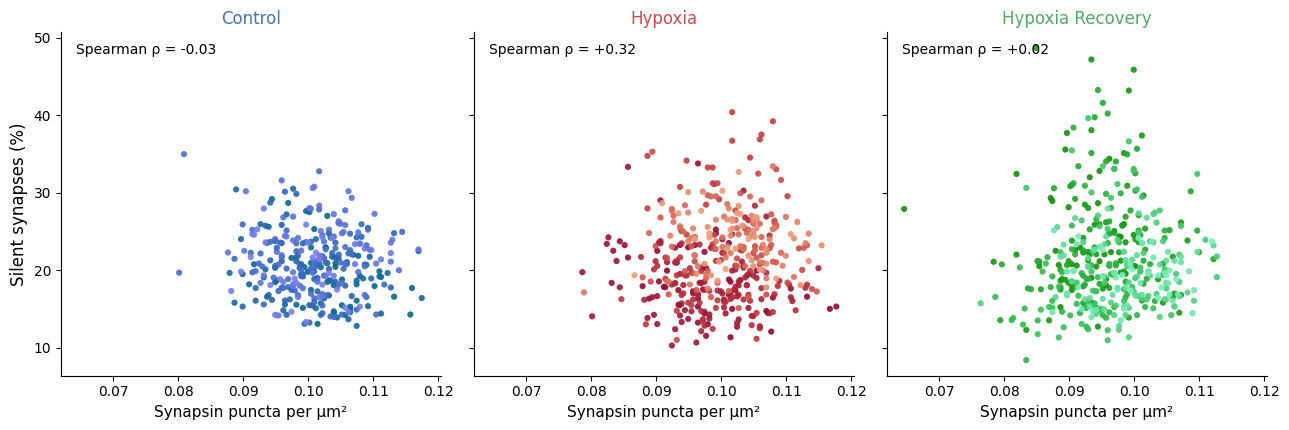

In [11]:
# Figure 9 - synapse density vs silencing, one panel per condition (sparse batches).
# Each dot is a field; fields from the same coverslip share a shade of the
# condition colour. Annotated Spearman rho is at the coverslip level (matching the report).
import matplotlib.colors as _mc
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
FIELD_AREA_UM2 = 3992.0   # 1280x960 px at 0.057 µm/px
spf = fields[fields.batch.isin(['24h','48h'])].copy()
spf['dens_um2'] = spf['n_syn'] / FIELD_AREA_UM2

def _shades(base, n):
    # spread coverslips across hue, saturation and value within the condition's
    # colour family so individual coverslips are easier to tell apart.
    import colorsys
    h, sat, val = colorsys.rgb_to_hsv(*_mc.to_rgb(base))
    if n <= 1:
        return [colorsys.hsv_to_rgb(h, sat, val)]
    out = []
    for i in range(n):
        t = i / (n - 1)
        hh = (h + (t - 0.5) * 0.11) % 1.0
        ss = 0.95 - 0.45 * t
        vv = 0.55 + 0.38 * t
        out.append(colorsys.hsv_to_rgb(hh, ss, vv))
    return out

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True, sharex=True)
for ax, c in zip(axes, CONDS):
    d = spf[spf.condition == c]
    keys = sorted(d.groupby(['batch', 'coverslip']).groups.keys())
    shs = _shades(COL[c], len(keys))
    for (b, cslip), sh in zip(keys, shs):
        dd = d[(d.batch == b) & (d.coverslip == cslip)]
        ax.scatter(dd.dens_um2, dd.pct_silent, color=[sh], s=20, alpha=0.9, edgecolors='none')
    cc = cs[(cs.batch.isin(['24h', '48h'])) & (cs.condition == c)]
    rho, _ = stats.spearmanr(cc.density, cc.silent)
    ax.set_title(LAB[c], color=COL[c], fontsize=12)
    ax.text(0.04, 0.97, f'Spearman ρ = {rho:+.2f}', transform=ax.transAxes, va='top', fontsize=10)
    ax.set_xlabel('Synapsin puncta per µm²', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.set_major_locator(MultipleLocator(0.01)); ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_locator(MultipleLocator(10))
axes[0].set_ylabel('Silent synapses (%)', fontsize=12)
fig.tight_layout(); plt.savefig('../figures/Figure9.png', dpi=200, bbox_inches='tight'); plt.show()
